# 03 - Amplify, then compress: rejection-sampling SFT and distillation

The last two moves of the R1 recipe, on the same toy task and the same single
metric (**pass-rate**) as notebooks 01-02.

- **Stage A - Rejection-sampling SFT (amplify).** Use the RL'd model as a *data
  factory*: have it generate several completions per prompt, keep only the
  correct ones, and supervised-fine-tune on that filtered set. The model learns
  from its own best outputs — no new labels, no new reward.
- **Stage B - Distillation (compress).** Train a much smaller *student* model to
  imitate the *teacher's* output distribution (KL on softened logits). The
  student reaches most of the teacher's pass-rate at a fraction of the
  parameters.

We end with a summary table and bar chart of pass-rate across the **whole**
recipe — cold-start -> GRPO -> reject-SFT -> distilled student — the payoff of
the entire course in one picture.

> Same compact `T`/`A` markers as notebook 02 (`T` = `<think>`, `A` = `<answer>`).
> All shared machinery is imported from `r1_toy.py`.

In [1]:
import os
import torch, torch.nn.functional as F, random, re
import r1_toy as R

torch.manual_seed(0); random.seed(0)

# Pick up notebook 02's GRPO checkpoint if present; otherwise train one inline
# so this notebook is fully self-contained (no hard dependency on a prior run).
model = R.TinyLM()
CKPT = 'nb2_after_grpo.pt'

if os.path.exists(CKPT):
    model.load_state_dict(torch.load(CKPT))
    print(f'loaded {CKPT}')
else:
    print(f'{CKPT} not found - quick-training a cold-start+GRPO model inline...')

    # --- inline cold-start SFT (20 examples) ---
    exs = R.all_examples(); random.shuffle(exs); sft = exs[:20]
    opt = torch.optim.AdamW(model.parameters(), lr=3e-3)
    for _ in range(400):
        x = R.pad_batch(random.choices(sft, k=16))
        logits = model(x[:, :-1])
        loss = F.cross_entropy(logits.reshape(-1, R.V), x[:, 1:].reshape(-1),
                               ignore_index=R.PAD)
        opt.zero_grad(); loss.backward(); opt.step()

    # --- inline GRPO ---
    def _grpo_step(prompt_str, G=4):
        pid = torch.tensor([R.encode(prompt_str)])
        logps, rewards = [], []
        for _ in range(G):
            full, lp = R.sample_completion(model, pid)
            comp = R.decode(full[0, len(pid[0]):].tolist())
            logps.append(lp); rewards.append(R.reward(prompt_str, comp))
        r = torch.tensor(rewards)
        adv = (r - r.mean()) / (r.std() + 1e-6)
        return -(torch.cat(logps) * adv).mean()

    opt = torch.optim.AdamW(model.parameters(), lr=1e-4)
    for _ in range(300):
        prompt, a, b = R.random_prompt()
        loss = _grpo_step(prompt)
        opt.zero_grad(); loss.backward(); opt.step()
    print('inline training done')

pr_grpo = R.pass_rate(model)
print('-' * 60)
print(f'starting pass-rate (after GRPO): {pr_grpo:.0%}')

loaded nb2_after_grpo.pt


------------------------------------------------------------
starting pass-rate (after GRPO): 30%


## Stage A - Rejection-sampling SFT (the model as a data factory)

The recipe:

1. For every prompt, **sample several completions** (with temperature, so they
   vary).
2. **Keep only the ones the reward checker accepts** (correct answer) — this is
   the "rejection" step: we reject the wrong ones.
3. **Supervised fine-tune** on the surviving, known-correct completions.

No new human labels and no new reward signal — just *cleaner data* the model
produced itself. R1 used this to stabilize a wobbly RL'd model into something
deployable, and it is the same trick behind modern self-improvement loops.

In [2]:
# Step 1+2: generate completions per prompt, keep the first correct one
def is_correct(text, a, b):
    m = re.search(r'A(\d+)\.', text)
    return m is not None and int(m.group(1)) == a + b

kept = []
for a in range(10):
    for b in range(10):
        for _ in range(12):                       # up to 12 tries per prompt
            out = R.sample_text(model, f'{a}+{b}=')
            if is_correct(out, a, b):
                kept.append(out)
                break

print(f'kept {len(kept)} / 100 prompts (correct, self-generated)')
for ex in kept[:5]:
    print('  ', ex)

kept 43 / 100 prompts (correct, self-generated)
   0+0=T0+0AA0.
   0+1=T0+10A1.
   0+2=T0+22A2.
   0+4=T0+48A4.
   0+5=T0+23A5.


In [3]:
# Step 3: SFT on the filtered, known-correct set
opt = torch.optim.AdamW(model.parameters(), lr=1e-3)
for step in range(300):
    x = R.pad_batch(random.choices(kept, k=16))
    logits = model(x[:, :-1])
    loss = F.cross_entropy(logits.reshape(-1, R.V), x[:, 1:].reshape(-1),
                           ignore_index=R.PAD)
    opt.zero_grad(); loss.backward(); opt.step()
    if step % 60 == 0:
        print(f'step {step:3d}  loss {loss.item():.3f}')

pr_reject = R.pass_rate(model)
torch.save(model.state_dict(), 'nb3_after_reject_sft.pt')
print('-' * 60)
print(f'PASS-RATE after GRPO            : {pr_grpo:.0%}')
print(f'PASS-RATE after rejection-SFT   : {pr_reject:.0%}')
print('saved nb3_after_reject_sft.pt')

step   0  loss 0.859


step  60  loss 0.206


step 120  loss 0.247


step 180  loss 0.195


step 240  loss 0.193


------------------------------------------------------------
PASS-RATE after GRPO            : 30%
PASS-RATE after rejection-SFT   : 38%
saved nb3_after_reject_sft.pt


**What to notice:** the model trained on *its own correct outputs* — no new
labels, no new reward — and the pass-rate rose / stabilized. Filtering for
correctness turns a noisy policy into clean supervised data.

## Stage B - Distillation (teacher -> smaller student)

The R1 paper's striking result: distilling a strong reasoning model into a
*small* one works **better** than running RL on the small one directly — because
the teacher already did the hard exploration.

We do the simplest possible version:

- **Teacher** = our reject-SFT model (`d=64, L=2`, ~104K params).
- **Student** = a half-width, single-layer model (`d=32, L=1`, ~14.5K params,
  roughly 1/7 the size).
- **Objective** = KL divergence between student and teacher next-token
  distributions, on *softened* logits (temperature `T=2`). The student is
  trained to match the teacher's full distribution, not just the argmax.

In [4]:
teacher = model
teacher.eval()
student = R.TinyLM(d=32, L=1)   # half width, single layer

print('teacher params:', round(R.n_params(teacher), 1), 'K')
print('student params:', round(R.n_params(student), 1), 'K')
print('compression  :', f'{R.n_params(teacher) / R.n_params(student):.1f}x smaller')

# Distillation set: the teacher's own greedy completion for every prompt
distill_set = [R.generate(teacher, f'{a}+{b}=') for a in range(10) for b in range(10)]
print('distill set size:', len(distill_set))

teacher params: 103.6 K
student params: 14.5 K
compression  : 7.1x smaller


distill set size: 100


In [5]:
opt = torch.optim.AdamW(student.parameters(), lr=3e-3)
T_temp = 2.0
for step in range(600):
    x = R.pad_batch(random.choices(distill_set, k=16))
    with torch.no_grad():
        t_logits = teacher(x[:, :-1]) / T_temp
    s_logits = student(x[:, :-1]) / T_temp
    loss = F.kl_div(F.log_softmax(s_logits, -1), F.softmax(t_logits, -1),
                    reduction='batchmean') * (T_temp ** 2)
    opt.zero_grad(); loss.backward(); opt.step()
    if step % 100 == 0:
        print(f'step {step:3d}  KL {loss.item():.3f}')

pr_teacher = R.pass_rate(teacher)
pr_student = R.pass_rate(student)
print('-' * 60)
print(f'teacher pass-rate ({R.n_params(teacher):.0f}K params): {pr_teacher:.0%}')
print(f'student pass-rate ({R.n_params(student):.0f}K params): {pr_student:.0%}')

step   0  KL 103.670


step 100  KL 15.049


step 200  KL 8.906


step 300  KL 5.690


step 400  KL 4.653


step 500  KL 4.332


------------------------------------------------------------
teacher pass-rate (104K params): 44%
student pass-rate (15K params): 36%


**What to notice:** a model with half the width and half the depth picked up
most of the teacher's skill from plain KL on logits. This is exactly why the
real R1 distilled checkpoints (Qwen-1.5B / 7B / 14B) punch so far above their
weight: the expensive RL exploration is done once by the teacher, then *copied*
cheaply into smaller students.

## The whole recipe in one picture

Pass-rate across every stage of the course — this is the payoff slide.

In [6]:
# Recover the cold-start number if NB2 left its checkpoint; else mark as n/a
pr_coldstart = None
if os.path.exists('nb2_cold_start.pt'):
    cs = R.TinyLM(); cs.load_state_dict(torch.load('nb2_cold_start.pt'))
    pr_coldstart = R.pass_rate(cs)

stages = []
if pr_coldstart is not None:
    stages.append(('cold-start SFT', pr_coldstart, '#bbbbbb'))
stages += [
    ('GRPO (RL)',        pr_grpo,    '#7fcdbb'),
    ('reject-SFT',       pr_reject,  '#41b6c4'),
    ('distilled student', pr_student, '#2c7fb8'),
]

print(f'{"stage":<22}{"pass-rate":>10}')
print('-' * 32)
for name, pr, _ in stages:
    print(f'{name:<22}{pr:>9.0%}')
print('-' * 32)
print(f'student is ~{R.n_params(teacher) / R.n_params(student):.0f}x smaller than the teacher')

stage                  pass-rate
--------------------------------
cold-start SFT               7%
GRPO (RL)                   30%
reject-SFT                  38%
distilled student           36%
--------------------------------
student is ~7x smaller than the teacher


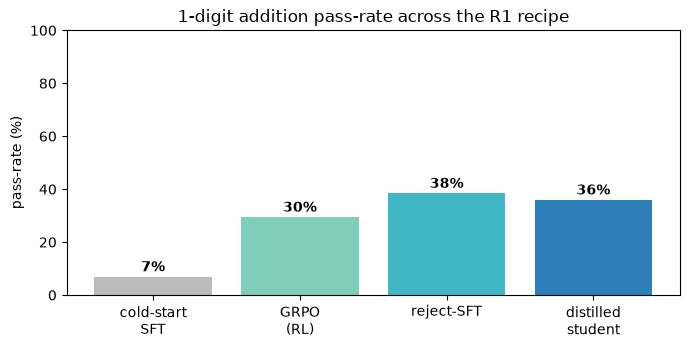

In [7]:
import matplotlib.pyplot as plt

labels = [s[0].replace(' ', '\n', 1) for s in stages]
vals = [s[1] * 100 for s in stages]
colors = [s[2] for s in stages]

fig, ax = plt.subplots(figsize=(7, 3.6))
bars = ax.bar(labels, vals, color=colors)
ax.set_ylabel('pass-rate (%)'); ax.set_ylim(0, 100)
ax.set_title('1-digit addition pass-rate across the R1 recipe')
for b in bars:
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 2,
            f'{b.get_height():.0f}%', ha='center', fontweight='bold')
plt.tight_layout(); plt.show()

## Takeaway

The whole arc, one task, one metric:

| Stage | Notebook | What it adds |
|---|---|---|
| Pre-train | 01 | Language (next-token prediction) |
| Cold-start SFT | 02 | **Format** (think -> answer) |
| RL (GRPO) | 02 | **Skill** (correct answers, from verifiable rewards) |
| Reject-SFT | 03 | **Stability** (train on own correct outputs) |
| Distill | 03 | **Efficiency** (most of the skill, a fraction of the size) |

That is the entire DeepSeek-R1 recipe, built from scratch and *measured* at
every step. A scratchpad helped (NB1); cold-start gave it shape; RL from a
rule-based reward gave it skill; rejection sampling cleaned it up; and
distillation compressed it. Same toy task throughout — the same machinery
scales to real reasoning models.